In [11]:
# ============================================================
# PART 1 — Setup, model, and large reference dataset
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import emcee, corner

np.random.seed(1234)
torch.manual_seed(1234)

# Global plot style
plt.rcParams.update({
    "font.family": "sans-serif",
    "mathtext.fontset": "dejavusans",
    "font.size": 14,
    "axes.labelsize": 17,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.0,
    "lines.linewidth": 1.8,
})

# Device
device = torch.device("cpu")
dtype  = torch.float32
print("Device:",device)

# Ground truth
r_true,phi_true,nth_true = 7.0,np.pi/4,0.10

def quad_var(r_dB,phi,nth,theta):
    r = r_dB*np.log(10)/20
    return (2*nth+1)/4 * (
        torch.cosh(2*r) - torch.sinh(2*r)*torch.cos(2*theta-phi)
    )

# Generate one large dataset
N_max      = 200000
phases_all = torch.rand(N_max,device=device,dtype=dtype)*np.pi

r_t   = torch.tensor(r_true,device=device,dtype=dtype)
phi_t = torch.tensor(phi_true,device=device,dtype=dtype)
nth_t = torch.tensor(nth_true,device=device,dtype=dtype)

var_all = quad_var(r_t,phi_t,nth_t,phases_all)
x_all   = torch.randn(N_max,device=device,dtype=dtype)*torch.sqrt(var_all)

print("Reference dataset size:",N_max)

Device: cpu
Reference dataset size: 200000


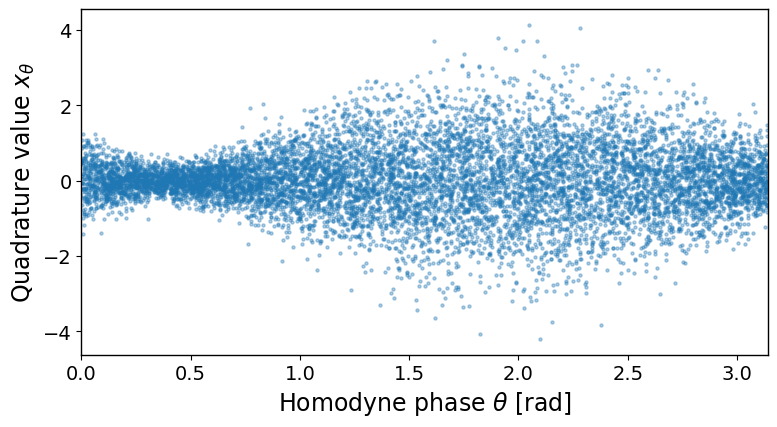

In [12]:
# ============================================================
# PART 2 — Simulated homodyne quadrature sequence
# ============================================================

N_plot = 10000

ph_plot = phases_all[:N_plot].cpu().numpy()
x_plot  = x_all[:N_plot].cpu().numpy()
order   = np.argsort(ph_plot)

plt.figure(figsize=(8,4.5))

plt.scatter(ph_plot[order],x_plot[order],s=5,alpha=0.35)

plt.xlabel(r"Homodyne phase $\theta$ [rad]")
plt.ylabel(r"Quadrature value $x_\theta$")
plt.xlim(0,np.pi)

plt.tight_layout()
plt.savefig("simulated_data_quadrature_sequence.pdf",bbox_inches="tight")
plt.show()

In [13]:
# ============================================================
# PART 3 — MCMC inference for a selected data size
# ============================================================

def run_mcmc(N_data,nsteps=5000,nwalkers=32,discard=1500,thin=5):
    phases,x = phases_all[:N_data],x_all[:N_data]

    def log_post(params):
        params = np.atleast_2d(params)
        r,phi,nth = params[:,0],params[:,1],params[:,2]

        valid = (
            (0 <= r) & (r <= 10) &
            (0 <= phi) & (phi < 2*np.pi) &
            (0 <= nth) & (nth <= 0.5)
        )

        out = np.full(len(params),-np.inf)
        if not np.any(valid): return out

        p = torch.as_tensor(params[valid],device=device,dtype=dtype)
        rr,pp,nn = p[:,0,None],p[:,1,None],p[:,2,None]

        V = torch.clamp(quad_var(rr,pp,nn,phases[None,:]),min=1e-12)
        logL = -0.5*(torch.log(2*np.pi*V) + x[None,:]**2/V)
        out[valid] = torch.sum(logL,dim=1).cpu().numpy()
        return out

    guess = np.array([6.0,0.9,0.15])
    spread = np.array([0.3,0.15,0.03])
    p0 = guess + spread*np.random.randn(nwalkers,3)

    p0[:,0] = np.clip(p0[:,0],1e-5,10-1e-5)
    p0[:,1] = np.mod(p0[:,1],2*np.pi)
    p0[:,2] = np.clip(p0[:,2],1e-5,0.5-1e-5)

    sampler = emcee.EnsembleSampler(nwalkers,3,log_post,vectorize=True)
    sampler.run_mcmc(p0,nsteps,progress=False)

    return sampler.get_chain(discard=discard,thin=thin,flat=True)

In [14]:
# ============================================================
# PART 4 — Data-size convergence study
# ============================================================

N_list = [50, 100, 200, 500, 1000, 2000, 5000, 10000,
          20000, 50000, 100000,150000, 200000]

results = []
saved_samples = {}

for N in N_list:
    print(f"Running N = {N}...")
    samples = run_mcmc(N)

    q16, q50, q84 = np.percentile(samples, [16, 50, 84], axis=0)
    results.append((N, q16, q50, q84))
    saved_samples[N] = samples

Ns      = np.array([r[0] for r in results])
q16s    = np.array([r[1] for r in results])
medians = np.array([r[2] for r in results])
q84s    = np.array([r[3] for r in results])
widths  = q84s - q16s

Running N = 50...
Running N = 100...
Running N = 200...
Running N = 500...
Running N = 1000...
Running N = 2000...
Running N = 5000...
Running N = 10000...
Running N = 20000...
Running N = 50000...
Running N = 100000...
Running N = 150000...
Running N = 200000...


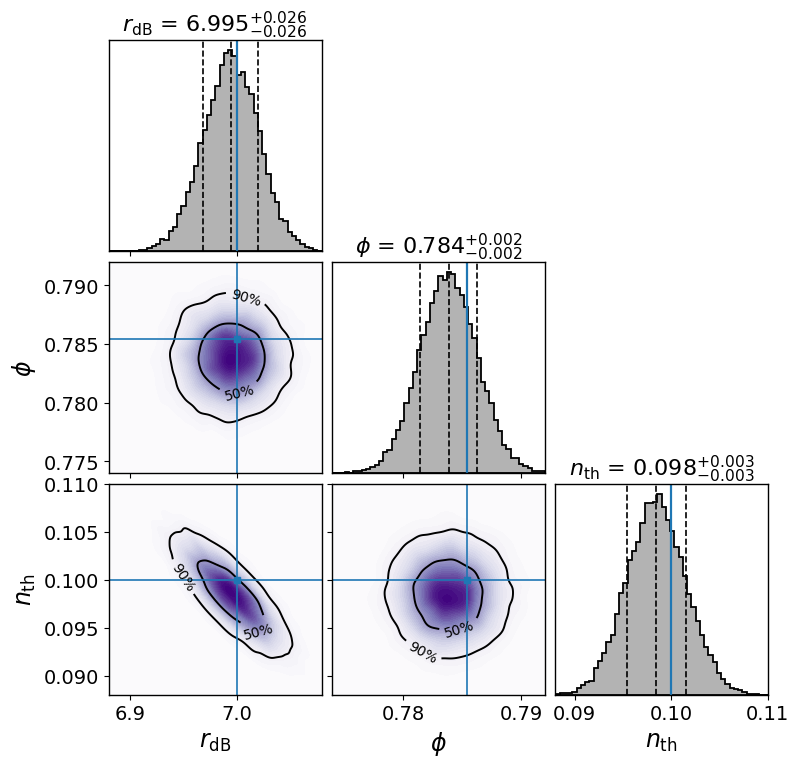

In [33]:
# ============================================================
# PART 5 — Triangle posterior plot
# ============================================================

from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

def kde_levels(Z, probs=(0.50,0.90)):
    z = np.sort(Z.ravel())[::-1]
    c = np.cumsum(z)/np.sum(z)
    return np.sort([z[min(np.searchsorted(c,p),len(z)-1)] for p in probs])

def triangle_posterior_plot(samples, truths, labels, ranges=None, gridsize=200, bins=50):
    ndim = samples.shape[1]

    if ranges is None:
        ranges = []
        for i in range(ndim):
            q   = np.percentile(samples[:,i],[0.5,99.5])
            pad = 0.08*(q[1]-q[0])
            ranges.append((q[0]-pad,q[1]+pad))

    fig,axs = plt.subplots(ndim,ndim,figsize=(8.5,8.5))
    plt.subplots_adjust(wspace=0.05,hspace=0.05)

    for i in range(ndim):
        for j in range(ndim):
            ax = axs[i,j]

            if i < j:
                ax.axis("off")
                continue

            x = samples[:,j]

            if i == j:
                q16,q50,q84 = np.percentile(x,[16,50,84])

                ax.hist(x,bins=bins,range=ranges[j],density=True,
                        histtype="stepfilled",color="0.7",
                        edgecolor="black",linewidth=1.3)

                ax.axvline(truths[j],color="C0",lw=1.6)

                for q in [q16,q50,q84]:
                    ax.axvline(q,color="black",ls="--",lw=1.2)

                ax.set_xlim(ranges[j])
                ax.set_yticks([])
                ax.set_title(
                    f"{labels[j]} = {q50:.3f}"
                    + rf"$^{{+{q84-q50:.3f}}}_{{-{q50-q16:.3f}}}$"
                )

            else:
                y   = samples[:,i]
                kde = gaussian_kde(np.vstack([x,y]))

                xx     = np.linspace(*ranges[j],gridsize)
                yy     = np.linspace(*ranges[i],gridsize)
                XX,YY  = np.meshgrid(xx,yy)
                Z      = kde(np.vstack([XX.ravel(),YY.ravel()])).reshape(XX.shape)
                levels = kde_levels(Z)

                ax.contourf(XX,YY,Z,levels=40,cmap="Purples")

                cs90 = ax.contour(
                    XX,YY,Z,levels=[levels[0]],
                    colors="black",linewidths=1.4
                )

                cs50 = ax.contour(
                    XX,YY,Z,levels=[levels[1]],
                    colors="black",linewidths=1.4
                )

                ax.clabel(
                    cs90,
                    fmt={levels[0]:"90%"},
                    inline=True,
                    fontsize=10
                )

                ax.clabel(
                    cs50,
                    fmt={levels[1]:"50%"},
                    inline=True,
                    fontsize=10,
                    manual=[(
                        truths[j]+0.1*(ranges[j][1]-ranges[j][0]),
                        truths[i]-0.5*(ranges[i][1]-ranges[i][0])
                    )]
                )

                ax.axvline(truths[j],color="C0",lw=1.2)
                ax.axhline(truths[i],color="C0",lw=1.2)
                ax.plot(truths[j],truths[i],"s",ms=5,color="C0")

                ax.set_xlim(ranges[j])
                ax.set_ylim(ranges[i])

            if i == ndim-1:
                ax.set_xlabel(labels[j])
            else:
                ax.set_xticklabels([])

            if j == 0 and i > 0:
                ax.set_ylabel(labels[i])
            elif i != j:
                ax.set_yticklabels([])

    return fig

N_show       = 200000
samples_show = saved_samples[N_show]

fig = triangle_posterior_plot(
    samples_show,
    truths=[r_true,phi_true,nth_true],
    labels=[r"$r_{\rm dB}$",r"$\phi$",r"$n_{\rm th}$"],
    ranges=[(6.88,7.08),(0.774,0.792),(0.088,0.110)]
)

plt.savefig("simulated_data_posterior_plot.pdf",bbox_inches="tight")
plt.show()

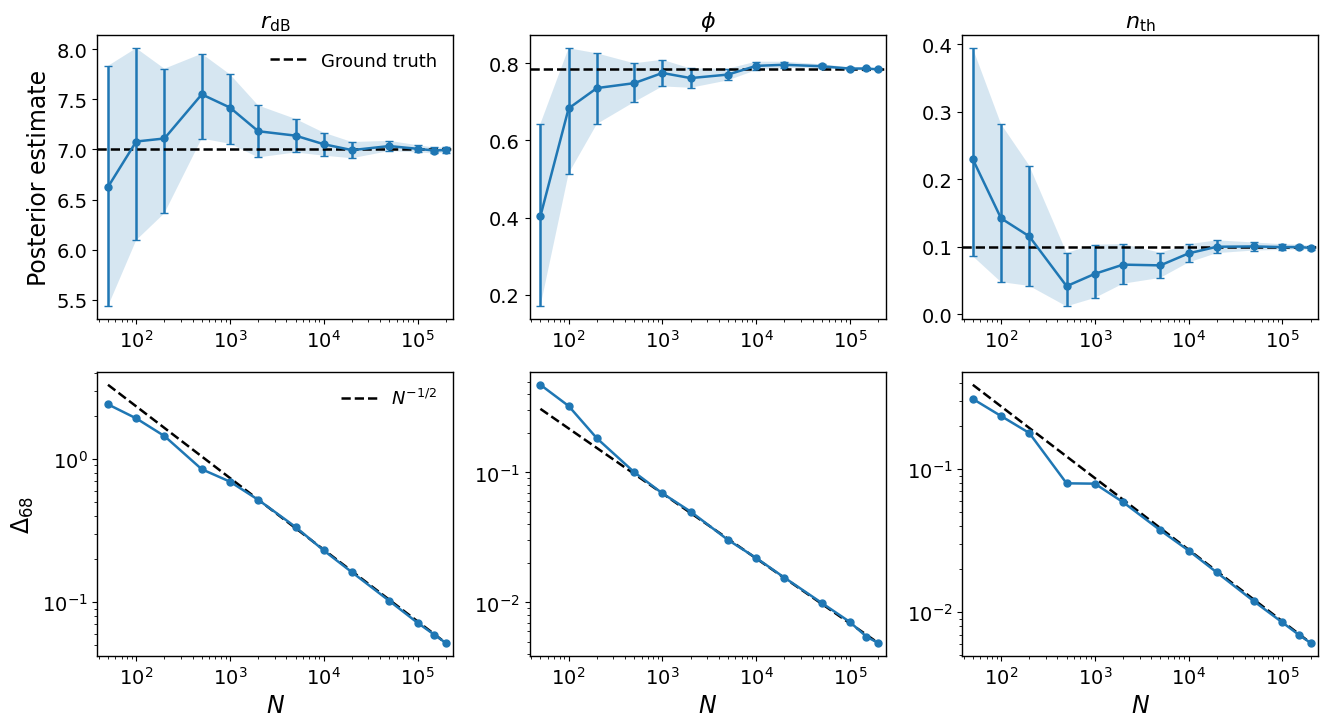

In [17]:
# ============================================================
# PART 6 — Bayesian convergence and posterior contraction
# ============================================================

labels = [r"$r_{\rm dB}$",r"$\phi$",r"$n_{\rm th}$"]
truths = [r_true,phi_true,nth_true]

fig,axs = plt.subplots(2,3,figsize=(13.5,7.5))

for i in range(3):

    # Top row: posterior estimates
    ax   = axs[0,i]
    yerr = np.vstack((medians[:,i]-q16s[:,i],
                      q84s[:,i]-medians[:,i]))

    ax.errorbar(Ns,medians[:,i],yerr=yerr,fmt="o-",ms=5,capsize=3)
    ax.fill_between(Ns,q16s[:,i],q84s[:,i],alpha=0.18)
    ax.axhline(truths[i],ls="--",color="black",label="Ground truth")

    ax.set_xscale("log")
    ax.set_xlim(Ns[0]/1.3,Ns[-1]*1.2)
    ax.set_title(labels[i])

    # Bottom row: posterior contraction
    ax  = axs[1,i]
    ref = widths[-1,i]*np.sqrt(Ns[-1]/Ns)

    ax.plot(Ns,ref,"--",color="black",label=r"$N^{-1/2}$",zorder=1)
    ax.plot(Ns,widths[:,i],"o-",ms=5,zorder=2)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(Ns[0]/1.3,Ns[-1]*1.2)
    ax.set_xlabel(r"$N$")

axs[0,0].set_ylabel("Posterior estimate")
axs[1,0].set_ylabel(r"$\Delta_{68}$")

axs[0,0].legend(frameon=False)
axs[1,0].legend(frameon=False)

plt.tight_layout()
plt.savefig("simulated_data_bayesian_convergence_and_contraction.pdf",
            bbox_inches="tight")
plt.show()

In [32]:
# ============================================================
# PART 7 — Fixed-axis posterior GIF
# ============================================================

import os
from PIL import Image

gif_N     = N_list
frame_dir = "corner_gif_frames"
os.makedirs(frame_dir,exist_ok=True)

plot_ranges = [(4.0,9.0),(0.4,1.2),(0.0,0.30)]   # r_dB, phi, n_th
frame_paths = []

for N in gif_N:
    fig = corner.corner(
        saved_samples[N],
        labels=labels,
        truths=truths,
        range=plot_ranges,
        quantiles=[0.16,0.50,0.84],
        show_titles=True,
        title_fmt=".3f",
        bins=30,
        smooth=1.0
    )

    fig.set_size_inches(8,8)
    fig.suptitle(rf"$N={N:,}$",y=0.98)
    fig.subplots_adjust(top=0.92)

    path = os.path.join(frame_dir,f"corner_N_{N:06d}.png")
    fig.savefig(path,dpi=120,facecolor="white")
    plt.close(fig)
    frame_paths.append(path)

frames = [Image.open(path) for path in frame_paths]
frames = [frames[0]]*2 + frames + [frames[-1]]*3

frames[0].save(
    "simulated_squeezed_thermal_posterior_convergence.gif",
    save_all=True,
    append_images=frames[1:],
    duration=300,
    loop=0
)

print("Saved: simulated_squeezed_thermal_posterior_convergence.gif")

Saved: simulated_squeezed_thermal_posterior_convergence.gif
